# Crumblr — Compositional Differential Abundance

Uses **crumblr** (CLR + dream mixed-effects) as an alternative to scCODA.  
Same dataset, same tissue × annotation-level grid.

**Setup (one-time):** `bash /home/gdallagl/myworkdir/XDP/data/crumblr/crumblr/setup_env.sh`  
**Kernel:** any env with `scanpy` + `pandas` (e.g. `python3`/`.venv`) — crumblr runs in its own venv via subprocess.

In [14]:
%load_ext autoreload
%autoreload 2

import os, subprocess, json, glob
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Image
import numpy as np

# ── Paths ─────────────────────────────────────────────────────────────────────
ADATA          = "/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/Striatum/Striatum_combined_QC_mmc_ct-cured_zoned.h5ad"

TISSUE         =  ADATA.split("/")[-2]
SAVE_FOLDER    = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/{TISSUE}"
CRUMBLR_SCRIPT = "/home/gdallagl/myworkdir/XDP/data/crumblr/crumblr/run_workflow.py"
MAPPING_JSON   = "/home/gdallagl/myworkdir/XDP/utils/STR_cell_types_annotation/group_level_mmc_mapping.json"

# ── Study design ──────────────────────────────────────────────────────────────
SAMPLE_COL     = "donor_id"
CONTRAST_COL   = "condition"
CONTRAST_REF   = "Control"
CONTRAST_STIM  = "XDP"
FIXED_EFFECTS  = ["sex", "cohort", "age_of_death"]  # fixed covariates
RANDOM_EFFECTS = []  # donor_id can't be a random effect: 1 sample per donor after aggregation → use lmFit

os.makedirs(SAVE_FOLDER, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
adata = sc.read_h5ad(ADATA, backed="r")
print(adata)
print("Cell counts by tissue:", adata.obs["tissue"].value_counts().to_dict())

AnnData object with n_obs × n_vars = 231080 × 38601 backed at '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/Striatum/Striatum_combined_QC_mmc_ct-cured_zoned.h5ad'
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'barcode', 'bcl', 'rna_index', 'library', 'library__barcode', 'frac_mito', 'mol_info_nUMI', 'mol_info_nRead', 'frac_intronic', 'donor_id', 'vireo_prob_max', 'vireo_prob_doublet', 'vireo_n_vars', 'vireo_best_singlet', 'vireo_best_doublet', 'vireo_doublet_logLikRatio', 'dropsift_frac_contamination', 'dropsift_training_label_is_cell', 'dropsift_empty_gene_module_score', 'dropsift_is_cell', 'dropsift_is_cell_prob', 'cell_class', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'tissue', 'broad_original_cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes

In [3]:
# Remove bad cell types 
adata = adata[~adata.obs["ct_for_deg"].str.startswith("-")].to_memory().copy()

## Helper functions

In [ ]:
import sys
sys.path.insert(0, "/home/gdallagl/myworkdir/XDP/data/crumblr")  # directory, not file path
from plot_crumblr import plot_all as _plot_all

# Columns that every CSV needs (cell-type col is added separately per run)
META_COLS = [SAMPLE_COL, CONTRAST_COL, *FIXED_EFFECTS]

# Subprocess env: override the Jupyter inline backend (invalid outside Jupyter)
_SUBPROCESS_ENV = {**os.environ, "MPLBACKEND": "Agg"}


def drop_bad_samples(adata):
    """Remove donors with any missing covariate."""
    bad = {s for col in META_COLS
              for s in adata.obs[adata.obs[col].isna()][SAMPLE_COL].unique()}
    return adata[~adata.obs[SAMPLE_COL].isin(bad)]

def filter_rare_celltypes(adata, ct_col, min_samples=5, min_cells_per_sample=3):
    """Remove cell types present in too few donors (would break lmFit)."""
    counts = (
        adata.obs[[ct_col, SAMPLE_COL]]
        .groupby([ct_col, SAMPLE_COL])
        .size()
        .reset_index(name="n_cells")
    )
    donor_counts = (
        counts[counts["n_cells"] >= min_cells_per_sample]
        .groupby(ct_col)[SAMPLE_COL]
        .nunique()
    )
    keep = donor_counts[donor_counts >= min_samples].index
    removed = set(adata.obs[ct_col].unique()) - set(keep)
    if removed:
        print(f"  removing {len(removed)} rare type(s): {sorted(removed)}")
    return adata[adata.obs[ct_col].isin(keep)]

def run_crumblr(adata_sub, ct_col, output_dir, label="", show=False):
    """
    Export a cell-level CSV, call run_workflow.py, then plot results with plot_crumblr.py.
    All CSVs + original PDFs/PNGs are saved to output_dir by run_workflow.py.
    Custom plots saved to output_dir/images/ by plot_crumblr.py.
    Returns the results DataFrame (one row per cell type × coefficient).
    """
    os.makedirs(output_dir, exist_ok=True)
    csv_path = os.path.join(output_dir, "cells.csv")

    # Write cell-level CSV (one row per cell, columns = ct + metadata)
    df = adata_sub.obs[[ct_col, *META_COLS]].dropna().copy()
    df[ct_col] = df[ct_col].astype(str)
    df.to_csv(csv_path, index=False)

    cmd = [
        "python", CRUMBLR_SCRIPT,
        "--csv",            csv_path,
        "--proportion-col", ct_col,
        "--sample-col",     SAMPLE_COL,   # one sample per donor → same as donor-col
        "--donor-col",      SAMPLE_COL,
        "--contrast",       CONTRAST_COL,
        "--ref-level",      CONTRAST_REF,
        "--output-dir",     output_dir,
        "--fixed-effects",  *FIXED_EFFECTS,
        "--random-effects", *RANDOM_EFFECTS,
    ]
    result = subprocess.run(cmd, capture_output=True, text=True, env=_SUBPROCESS_ENV)
    print(result.stdout[-2000:])  # trim output to avoid flooding the notebook
    if result.returncode != 0:
        print("STDERR:", result.stderr[-2000:])
        raise RuntimeError(f"crumblr failed → {output_dir}")

    # Custom plots: use actual cell type names, no internal class mapping
    _plot_all(output_dir, contrast_col=CONTRAST_COL, contrast_stim=CONTRAST_STIM, label=label, show=show)

    return pd.read_csv(os.path.join(output_dir, "crumblr_results.csv"))


def run_crumblr_grid(adata, annotation_levels, out_dir, show=False):
    """Run crumblr for every annotation level on the tissue adata."""

    # remove samples with nan in some metadata
    adata = drop_bad_samples(adata).to_memory().copy()

    df_list = []
    for ct_col in annotation_levels:
        
        label = f"{TISSUE} | {ct_col}"
        print(f"\n{'='*60}\n{label}")
        print(adata.obs[ct_col].value_counts())

        # remove ct with too few cells or samples
        adata_ct = filter_rare_celltypes(adata, ct_col, min_samples=5, min_cells_per_sample=3)

        ct_out_dir = f"{out_dir}/{ct_col}"
        df = run_crumblr(adata_ct, ct_col, ct_out_dir, label=label, show=show)
        df["tissue"]     = TISSUE
        df["annotation"] = ct_col
        df_list.append(df)

    merged = pd.concat(df_list, ignore_index=True)
    merged.to_csv(f"{out_dir}/merged_results.csv", index=False)
    return merged

## All cells

using all cells, for each annotation granularity level.

In [4]:
# # spn_type / spn_receptor_type are not obs columns — derive them from Group_name via the JSON mapping
# with open(MAPPING_JSON) as f:
#     classifications = json.load(f)

# for col in ["spn_type", "spn_receptor_type"]:
#     if col not in adata.obs.columns:
#         adata.obs[col] = adata.obs["Group_name"].map(classifications[col]).fillna(adata.obs["Group_name"])


zone
Using Astrocyte to assign zones to ['Astrocyte']
zone_assigned_by_Astrocyte
Oligo OPALIN                      114522
Microglia                          10592
Oligo PLEKHG1                       8841
Astrocyte                           8364
OPC                                 7777
1_Astrocyte                         6948
STRd D2 Matrix MSN                  6711
STRd D1 Matrix MSN                  6223
STRv D1 MSN                         5473
STRv D2 MSN                         4840
STRd D1 Striosome MSN               4132
2_Astrocyte                         4031
4_Astrocyte                         3840
STRd D2 Striosome MSN               2995
3_Astrocyte                         2773
STR D1D2 Hybrid MSN                 2654
STR FS PTHLH-PVALB GABA             2131
STR TAC3-PLPP4 GABA                 1804
5_Astrocyte                         1764
6_Astrocyte                         1596
Ependymal                           1538
STRv D1 NUDAP MSN                   1507
AMY-SLEA-BNST GA

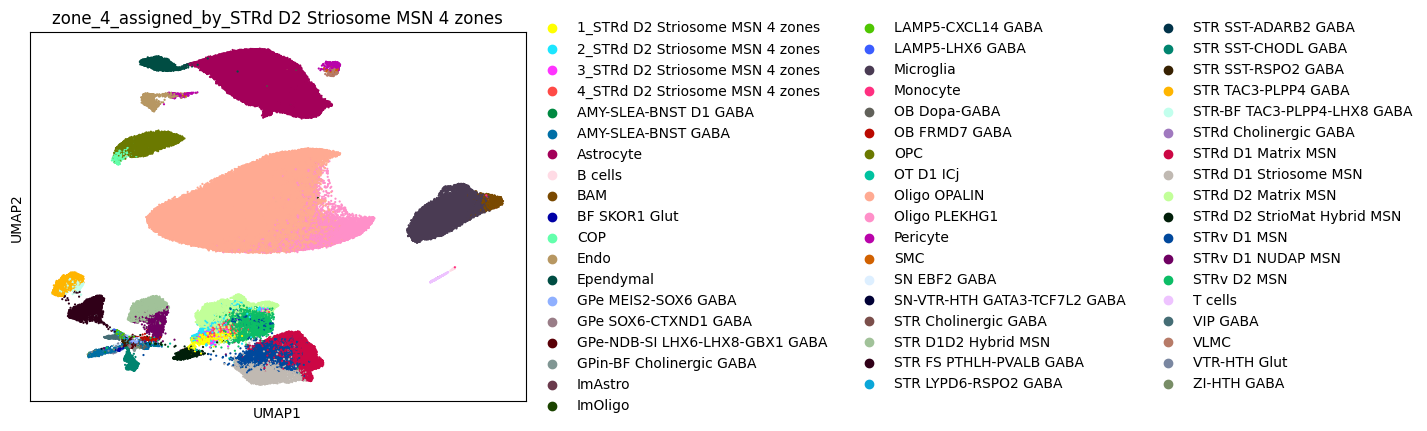

In [61]:
if TISSUE == "Striatum":
    
    col_zoning = []

    for col_coupling, col_zones in [("mapping_coupling_for_zoning", "zone"), ("mapping_coupling_for_zoning_4_zones", "zone_4")]:
        
        print(f"\n{col_zones}")

        for ct_used_for_zoning in adata.obs[col_coupling].unique().tolist():
            
            if pd.isna(ct_used_for_zoning) or adata.obs.loc[adata.obs[col_coupling] == ct_used_for_zoning, col_zones].isna().all():
                continue
            
            # Get the group names of th e cell types that use this cell type for zoning
            group_name_ct_that_use_this_ct_for_zoning = adata.obs.loc[adata.obs[col_coupling] == ct_used_for_zoning, "Group_name"].unique().tolist()
            print(f"Using {ct_used_for_zoning} to assign zones to {group_name_ct_that_use_this_ct_for_zoning}")

            # Create labels
                # zones for the cell types that use this ct for zoning
                # "Other" for all other cell types
            zone_col = f"{col_zones}_assigned_by_{ct_used_for_zoning}"
            mask = adata.obs["Group_name"].isin(group_name_ct_that_use_this_ct_for_zoning)
            zone_vals = adata.obs[col_zones].astype(str)

            adata.obs[zone_col] = adata.obs["Group_name"].astype(str)  # default: actual group name
            valid_mask = mask & adata.obs[col_zones].notna()
            adata.obs.loc[valid_mask, zone_col] = zone_vals[valid_mask] + "_" + ct_used_for_zoning

            col_zoning.append(zone_col)

            print(adata.obs[zone_col].value_counts())
    sc.pl.umap(adata, color=zone_col, size=10, title=zone_col)


In [ ]:
LEVELS_ALL = ["ct_for_deg", "Class_name", "Subclass_name", "Group_name"]
if TISSUE == "Striatum":
    LEVELS_ALL = LEVELS_ALL + col_zoning # "spn_type", "spn_receptor_type"]

df_all = run_crumblr_grid(adata, annotation_levels=LEVELS_ALL, out_dir = f"{SAVE_FOLDER}/all_cells", show=False)
df_all.head()

## Neurons only

Exclude non-neuronal cells. Groups not in the JSON mapping are labelled `NON_MSN` (the reference category).

In [ ]:
#filter onyl neruons
adata_n = adata[adata.obs["Neighborhood_name"] != "Nonneuron"].to_memory().copy()

LEVELS_NEURONS = ["ct_for_deg", "Class_name", "Subclass_name", "Group_name"]

df_neurons = run_crumblr_grid(adata_n, annotation_levels=LEVELS_NEURONS, out_dir = f"{SAVE_FOLDER}/only_neurons", show=False)
df_neurons.head()

del adata_n

# Zones - Striatum - Only specific cell type

In [76]:
if TISSUE == "Striatum":
    df_zones_list = []

    # loop over both zoning schemes (6-zone and 4-zone)
    for col_coupling, col_zones in [("mapping_coupling_for_zoning", "zone"), ("mapping_coupling_for_zoning_4_zones", "zone_4")]:
        for ct_used_for_zoning in adata.obs[col_coupling].unique().tolist():

            # skip NaN entries and cell types where all zone values are NaN
            if pd.isna(ct_used_for_zoning) or adata.obs.loc[adata.obs[col_coupling] == ct_used_for_zoning, col_zones].isna().all():
                continue

            # cell types that borrow their zone assignments from ct_used_for_zoning
            groups = adata.obs.loc[adata.obs[col_coupling] == ct_used_for_zoning, "Group_name"].unique().tolist()
            print(f"\n{col_zones} | {ct_used_for_zoning} → {groups}")

            # subset to this cell type only; remove donors with missing covariates; drop unzoned cells
            adata_sub = adata[adata.obs["Group_name"].isin(groups)].to_memory().copy()
            adata_sub = drop_bad_samples(adata_sub).copy()
            adata_sub = adata_sub[adata_sub.obs[col_zones].notna()].copy()

            # prefix zone numbers with "zone_" so R doesn't parse them as integers
            adata_sub.obs["zone_labeled"] = "zone_" + adata_sub.obs[col_zones].astype(str)
            print(adata_sub.obs["zone_labeled"].value_counts())

            safe_name = ct_used_for_zoning.replace(" ", "_").replace("/", "-")
            out_dir = f"{SAVE_FOLDER}/only_zone/{col_zones}/{safe_name}"

            try:
                df = run_crumblr(adata_sub, "zone_labeled", out_dir, label=f"{col_zones} | {ct_used_for_zoning}", show=False)
                df["ct_used_for_zoning"] = ct_used_for_zoning
                df["zone_col"]           = col_zones
                df_zones_list.append(df)
            except RuntimeError as e:
                print(f"  skipping (crumblr failed): {e}")
                continue

    df_zones_per_ct = pd.concat(df_zones_list, ignore_index=True)
    df_zones_per_ct.to_csv(f"{SAVE_FOLDER}/only_zone/all_results.csv", index=False)
    df_zones_per_ct



zone | Astrocyte → ['Astrocyte']
zone_labeled
zone_1    6948
zone_2    4030
zone_4    3840
zone_3    2773
zone_5    1764
zone_6    1596
Name: count, dtype: int64
[1/6] Loading /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/Striatum/only_zone/zone/Astrocyte/cells.csv …
[2/6] Aggregating cell counts …
  Dropping 3 sample(s) with < 100 cells: ['SCF_22_065CM', 'SCF_23-081CM', 'SCF_23_072CF']
  Contrast 'condition' detected as categorical.
  Samples: 44  |  Cell types: 6
[3/6] Formula: ~ condition + sex + cohort + age_of_death
[4/6] Running crumblr (R) …

[R] /home/gdallagl/myworkdir/XDP/data/crumblr/micromamba_root/envs/crumblr/bin/Rscript … formula='~ condition + sex + cohort + age_of_death'
── Loading data ────────────────────────────────────────────────────────
  Samples: 44  |  Cell types: 6
  Formula: ~ condition + sex + cohort + age_of_death
  Contrast variable: condition
── Running crumblr ─────────────────────────────────────────────────────
── Fitting dream mo

In [ ]:
# # must match run_workflow.py argument defaults
# MIN_CELLS_PER_DONOR    = 100   # --min-n-cells
# MIN_CELLS_PER_CATEGORY = 150   # --min-n-cells-category

# if TISSUE == "Striatum":
#     df_zones_list = []

#     for col_coupling, col_zones in [("mapping_coupling_for_zoning", "zone"), ("mapping_coupling_for_zoning_4_zones", "zone_4")]:
#         for ct_used_for_zoning in adata.obs[col_coupling].unique().tolist():

#             # skip NaN entries and cell types where all zone values are NaN
#             if pd.isna(ct_used_for_zoning) or adata.obs.loc[adata.obs[col_coupling] == ct_used_for_zoning, col_zones].isna().all():
#                 continue

#             # cell types that borrow their zone assignments from ct_used_for_zoning
#             groups = adata.obs.loc[adata.obs[col_coupling] == ct_used_for_zoning, "Group_name"].unique().tolist()
#             print(f"\n{col_zones} | {ct_used_for_zoning} → {groups}")

#             # subset to this cell type only; remove donors with missing covariates; drop unzoned cells
#             adata_sub = adata[adata.obs["Group_name"].isin(groups)].to_memory().copy()
#             adata_sub = drop_bad_samples(adata_sub).copy()
#             adata_sub = adata_sub[adata_sub.obs[col_zones].notna()].copy()

#             # prefix zone numbers with "zone_" so R doesn't parse them as integers
#             adata_sub.obs["zone_labeled"] = "zone_" + adata_sub.obs[col_zones].astype(str)

#             # mirror run_workflow.py step 1: drop zones with < MIN_CELLS_PER_CATEGORY total cells
#             zone_counts = adata_sub.obs["zone_labeled"].value_counts()
#             valid_zones = zone_counts[zone_counts >= MIN_CELLS_PER_CATEGORY].index
#             adata_sub = adata_sub[adata_sub.obs["zone_labeled"].isin(valid_zones)].copy()

#             # mirror run_workflow.py step 2: drop donors with < MIN_CELLS_PER_DONOR total cells
#             # must happen AFTER zone filter — removing zones reduces per-donor cell counts
#             cells_per_donor = adata_sub.obs.groupby(SAMPLE_COL, observed=True).size()
#             valid_donors = cells_per_donor[cells_per_donor >= MIN_CELLS_PER_DONOR].index
#             adata_sub = adata_sub[adata_sub.obs[SAMPLE_COL].isin(valid_donors)].copy()

#             # check enough zones survive
#             if adata_sub.obs["zone_labeled"].nunique() < 2:
#                 print("  skipping: fewer than 2 zones after filtering")
#                 continue

#             # check at donor level — one row per donor after pseudobulk aggregation
#             donor_meta = adata_sub.obs[[SAMPLE_COL] + [CONTRAST_COL] + FIXED_EFFECTS].drop_duplicates(subset=SAMPLE_COL)

#             # need enough donors to fit the model (intercept + contrast + fixed effects)
#             min_donors = len(FIXED_EFFECTS) + 3
#             if len(donor_meta) < min_donors:
#                 print(f"  skipping: only {len(donor_meta)} donors (need ≥ {min_donors})")
#                 continue

#             # each covariate must have ≥ 2 levels across donors
#             # .astype(str) avoids Categorical retaining unused levels from the full dataset
#             if any(donor_meta[c].astype(str).nunique() < 2 for c in [CONTRAST_COL] + FIXED_EFFECTS):
#                 low = [c for c in [CONTRAST_COL] + FIXED_EFFECTS if donor_meta[c].astype(str).nunique() < 2]
#                 print(f"  skipping: {low} has < 2 levels across donors")
#                 continue

#             print(adata_sub.obs["zone_labeled"].value_counts())

#             safe_name = ct_used_for_zoning.replace(" ", "_").replace("/", "-")
#             out_dir = f"{SAVE_FOLDER}/only_zone/{col_zones}/{safe_name}"

#             df = run_crumblr(adata_sub, "zone_labeled", out_dir, label=f"{col_zones} | {ct_used_for_zoning}", show=False)
#             df["ct_used_for_zoning"] = ct_used_for_zoning
#             df["zone_col"]           = col_zones
#             df_zones_list.append(df)

#     df_zones_per_ct = pd.concat(df_zones_list, ignore_index=True)
#     df_zones_per_ct.to_csv(f"{SAVE_FOLDER}/only_zone/all_results.csv", index=False)
#     df_zones_per_ct



zone | Astrocyte → ['Astrocyte']
zone_labeled
zone_1    6880
zone_2    3984
zone_4    3792
zone_3    2732
zone_5    1734
zone_6    1572
Name: count, dtype: int64
[1/6] Loading /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/Striatum/only_zone/zone/Astrocyte/cells.csv …
[2/6] Aggregating cell counts …
  Contrast 'condition' detected as categorical.
  Samples: 44  |  Cell types: 6
[3/6] Formula: ~ condition + sex + cohort + age_of_death
[4/6] Running crumblr (R) …

[R] /home/gdallagl/myworkdir/XDP/data/crumblr/micromamba_root/envs/crumblr/bin/Rscript … formula='~ condition + sex + cohort + age_of_death'
── Loading data ────────────────────────────────────────────────────────
  Samples: 44  |  Cell types: 6
  Formula: ~ condition + sex + cohort + age_of_death
  Contrast variable: condition
── Running crumblr ─────────────────────────────────────────────────────
── Fitting dream model ─────────────────────────────────────────────────
── Extracting results ──────────────

RuntimeError: crumblr failed → /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/Striatum/only_zone/zone/STRd_D2_Striosome_MSN

## Zones — Striatum - D1 Matrix MSN only

Spatial zones are treated as the cell-type dimension (same as the last scCODA analysis).

Uses curated cell type annotation.

In [ ]:
# adata_z = sc.read_h5ad(
#     "/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/NucSeq_Striatum_curated_labelels_for_deg_zoned.h5ad",
#     backed="r"
# )

# adata_d1 = adata_z[
#     adata_z.obs["Group_name"].isin(["STRd D1 Matrix MSN", "STRv D1 MSN"]) &
#     (adata_z.obs["ct_for_deg"] == "Matrix")
# ].to_memory().copy()

# adata_d1 = drop_bad_samples(adata_d1).copy()

# # Prefix zone numbers with "zone_" so pandas never parses them as integers
# # (run_workflow.py reads counts_matrix.csv and crashes if column names are int)
# adata_d1.obs["zone"] = "zone_" + adata_d1.obs["zone"].astype(str)
# print(adata_d1.obs["zone"].value_counts())

# out_dir_z = f"{SAVE_FOLDER}/zones/Striatum/zone"
# df_zones  = run_crumblr(adata_d1, "zone", out_dir_z, label="zones | Striatum | zone", show=False)
# df_zones["tissue"]     = "Striatum"
# df_zones["annotation"] = "zone"
# df_zones.to_csv(f"{SAVE_FOLDER}/zones/results.csv", index=False)
# df_zones

## Summary — significant hits across all analyses

In [ ]:
# from plot_crumblr import plot_logfc_bar

# # Tag and merge everything
# df_all["cell_used"]     = "all_cells"
# df_neurons["cell_used"] = "only_neurons"
# df_zones["cell_used"]   = "zones"

# df_merged = pd.concat([df_all, df_neurons, df_zones], ignore_index=True)
# df_merged.to_csv(f"{SAVE_FOLDER}/all_results.csv", index=False)

# # Re-plot logFC bars per run from saved output directories (reads crumblr_results.csv directly)
# for (cell_used, tissue, ann) in df_merged[["cell_used", "tissue", "annotation"]].drop_duplicates().values:
#     out_dir = f"{SAVE_FOLDER}/{cell_used}/{tissue}/{ann}"
#     print(f"\n{cell_used} | {tissue} | {ann}")
#     plot_logfc_bar(out_dir, contrast_stim=CONTRAST_STIM, save=False)